In [28]:
import os
import copy
from typing import Tuple
import warnings

import numpy as np
import pandas as pd
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torchvision.transforms import v2 as T
from torchvision.models import resnet18, ResNet18_Weights

In [29]:
seed = 42

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

batch_size = 16

root_path = "/home/stefan/ioai-prep/kits/aicc/round-0/brain-tumor"
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"

warnings.filterwarnings("ignore")

# 1. Data processing

In [30]:
Weak = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.PILToTensor(),
    T.ToDtype(torch.float32, scale=True)
])

Strong = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomResizedCrop(224, scale=(0.5, 1.0)),
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    T.PILToTensor(),
    T.ToDtype(torch.float32, scale=True)
])

In [31]:
class BrainTumorDataset(Dataset):
    def __init__(self, is_train: bool):
        super().__init__()
        self.is_train = is_train
        self.ds_path = f"{root_path}/{'train' if is_train else 'test'}"
        self.paths = os.listdir(self.ds_path)
        self.transforms = Weak if not is_train else lambda img: (Weak(img), Strong(img))

    def __getitem__(self, idx):
        img_path = f"{self.ds_path}/{self.paths[idx]}"
        img = Image.open(img_path).convert("RGB")
        if not self.is_train:
            return Weak(img)
        return Weak(img), Strong(img)

    def __len__(self):
        return len(self.paths)

In [32]:
train_ds = BrainTumorDataset(is_train=True)
test_ds = BrainTumorDataset(is_train=False)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [33]:
# sanity check
x = next(iter(train_loader))
[b.shape for b in x]

[torch.Size([16, 3, 224, 224]), torch.Size([16, 3, 224, 224])]

# 2. Model

In [34]:
class FixMatch(nn.Module):
    """Minimal FixMatch w/ ResNet18 backbone."""
    def __init__(self, n_classes: int = 4, threshold: float = 0.95):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.backbone.fc = nn.Identity()  # remove FC
        self.classifier = nn.Linear(512, n_classes)
        self.threshold = threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.backbone(x)
        return self.classifier(feat)

    def weak_strong_pairs(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Apply weak/strong augmentations and return logits for both."""
        w = Weak(x) if isinstance(x, Image.Image) else torch.stack([Weak(Image.fromarray(i.permute(1, 2, 0).byte().cpu().numpy()).convert("RGB")) for i in x])
        s = Strong(x) if isinstance(x, Image.Image) else torch.stack([Strong(Image.fromarray(i.permute(1, 2, 0).byte().cpu().numpy()).convert("RGB")) for i in x])
        return w.to(device), s.to(device)

In [35]:
model = FixMatch(n_classes=4, threshold=0.95).to(device)

# sanity check
x = next(iter(train_loader))[0]
y = model(x.to(device))
y.shape

torch.Size([16, 4])

# 3. SSL Pretraining

In [36]:
def fixmatch_loss(model: FixMatch, x_w: torch.Tensor, x_s: torch.Tensor) -> torch.Tensor:
    """Compute supervised + unsupervised loss."""
    logits_w = model(x_w)
    logits_s = model(x_s)

    # pseudo-label from weak branch
    probs = torch.softmax(logits_w.detach(), dim=1)
    max_probs, targets = probs.max(1)
    mask = max_probs.ge(model.threshold).float()

    # cross-entropy on strong branch
    ce = nn.functional.cross_entropy(logits_s, targets, reduction="none")
    return (ce * mask).mean() + nn.functional.cross_entropy(logits_w, targets)

In [ ]:
epochs = 5
lr = 2e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
warmup = LinearLR(optimizer, start_factor=0.1, total_iters=3)
cosine = CosineAnnealingLR(optimizer, T_max=epochs-3)
sched = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])

scaler = torch.amp.GradScaler(device)

In [38]:
model.train()
losses = []

for epoch in range(epochs):
    running = 0.0
    for x_w, x_s in tqdm(train_loader, desc=f"FixMatch epoch {epoch+1}/{epochs}"):
        x_w, x_s = x_w.to(device, memory_format=torch.channels_last), x_s.to(device, memory_format=torch.channels_last)

        with torch.amp.autocast(device):
            loss = fixmatch_loss(model, x_w, x_s)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        losses.append(loss.item())
    sched.step()
    print(f"Epoch {epoch+1} | loss: {running / len(train_loader):.4f}")

torch.save(model.state_dict(), "fixmatch.pth")

FixMatch epoch 1/5: 100%|██████████| 125/125 [00:19<00:00,  6.45it/s]


Epoch 1 | loss: 0.4469


FixMatch epoch 2/5: 100%|██████████| 125/125 [00:19<00:00,  6.31it/s]


Epoch 2 | loss: 0.1247


FixMatch epoch 3/5: 100%|██████████| 125/125 [00:18<00:00,  6.83it/s]


Epoch 3 | loss: 0.1096


FixMatch epoch 4/5: 100%|██████████| 125/125 [00:18<00:00,  6.84it/s]


Epoch 4 | loss: 0.1264


FixMatch epoch 5/5: 100%|██████████| 125/125 [00:18<00:00,  6.61it/s]


ZeroDivisionError: float division by zero

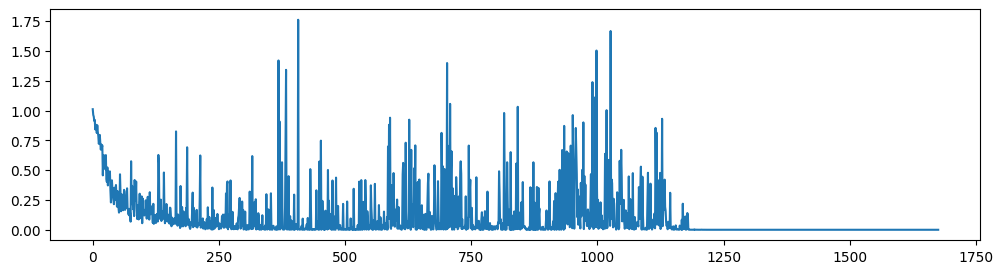

In [ ]:
plt.figure(figsize=(12, 3))
plt.plot(losses)

# 4. Classification fine-tuning

In [ ]:
model.load_state_dict(torch.load("fixmatch.pth"))

# freeze backbone for quick linear-probe
for p in model.backbone.parameters():
    p.requires_grad = False

classifier = nn.Sequential(model.backbone, model.classifier).to(device)

FileNotFoundError: [Errno 2] No such file or directory: 'fixmatch.pth'

In [ ]:
class LabeledDataset(Dataset):
    def __init__(self):
        super().__init__()

        self.label_encoder = LabelEncoder()

        self.df = pd.read_csv(f"{root_path}/train.csv")
        self.df["image_id"] = self.df["image_id"].map(lambda x: f"{x:04d}")
        self.df["label"] = self.label_encoder.fit_transform(self.df["label"])

        self.ids = self.df["image_id"].values
        self.paths = [f"{root_path}/train/{i}.jpg" for i in self.ids]

        self.transforms = T.Compose([
            T.Resize((224, 224)),
            T.PILToTensor(),
            T.RandomHorizontalFlip(),
            T.ColorJitter(0.4, 0.4, 0.4, 0.1),
            T.ToDtype(torch.float32, scale=True),
        ])

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        img = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.df["label"].values[idx])
        return self.transforms(img), label
    
    def __len__(self):
        return len(self.ids)

In [ ]:
labeled_ds = LabeledDataset()
labeled_loader = DataLoader(labeled_ds, batch_size, shuffle=True)

batch = next(iter(labeled_loader))
[b.shape for b in batch]

[torch.Size([16, 3, 224, 224]), torch.Size([16])]

In [ ]:
epochs = 7

optimizer = torch.optim.AdamW(classifier.parameters(), lr=2e-4)
ce_loss = nn.CrossEntropyLoss()

classifier.train()
losses = []

for epoch in range(epochs):
    running_loss = 0

    for x, y in tqdm(labeled_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        x = x.to(device, memory_format=torch.channels_last)
        y = y.to(device)
        
        with torch.amp.autocast(device):
            y_pred = classifier(x)
            loss = ce_loss(y_pred, y)

        classifier.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        losses.append(loss.item())
    print(f"Epoch {epoch+1} | loss: {running_loss / len(labeled_loader):.4f}")

Epoch 1/7: 100%|██████████| 3/3 [00:00<00:00,  7.80it/s]


Epoch 1 | loss: 1.1356


Epoch 2/7: 100%|██████████| 3/3 [00:00<00:00,  8.10it/s]


Epoch 2 | loss: 0.3090


Epoch 3/7: 100%|██████████| 3/3 [00:00<00:00,  7.82it/s]


...

Epoch 5 | loss: 0.0186


Epoch 6/7: 100%|██████████| 3/3 [00:00<00:00,  8.24it/s]


Epoch 6 | loss: 0.0047


Epoch 7/7: 100%|██████████| 3/3 [00:00<00:00,  8.08it/s]

Epoch 7 | loss: 0.0027


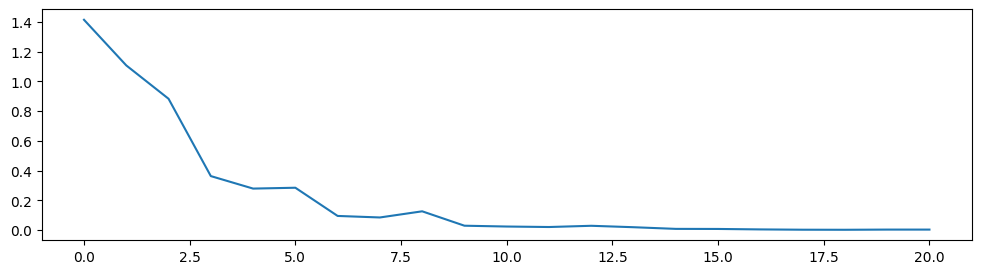

In [ ]:
plt.figure(figsize=(12, 3))
plt.plot(losses)

In [ ]:
torch.save(classifier.state_dict(), "pretrained_byol.pth")

# 5. Pseudo-labeling finetune

In [ ]:
classifier.load_state_dict(torch.load("pretrained_byol.pth"))

<All keys matched successfully>

In [ ]:
class LabeledDataset(Dataset):
    def __init__(self, df: pd.DataFrame, root_path: str, label_encoder: LabelEncoder):
        self.df = df.reset_index(drop=True)
        self.paths = [f"{root_path}/train/{x:04d}.jpg" for x in self.df["image_id"]]
        self.labels = label_encoder.transform(self.df["label"])
        self.transforms = T.Compose([
            T.Resize((224, 224)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(0.2, 0.2, 0.2, 0.1),
            T.PILToTensor(),
            T.ToDtype(torch.float32, scale=True),
        ])

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transforms(img), torch.tensor(self.labels[idx])

    def __len__(self):
        return len(self.paths)


class UnlabeledDataset(Dataset):
    def __init__(self, df: pd.DataFrame, root_path: str):
        self.df = df.reset_index(drop=True)
        self.paths = [f"{root_path}/train/{x:04d}.jpg" for x in self.df["image_id"]]
        self.transforms = T.Compose([
            T.Resize((224, 224)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(0.2, 0.2, 0.2, 0.1),
            T.PILToTensor(),
            T.ToDtype(torch.float32, scale=True),
        ])

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transforms(img), -1  # dummy label

    def __len__(self):
        return len(self.paths)

In [ ]:
# Split train.csv into labeled (2%) and unlabeled sets
df = pd.read_csv(f"{root_path}/train.csv")
df["image_id"] = df["image_id"].map(lambda x: int(x))  # ensure int IDs

label_encoder = LabelEncoder()
label_encoder.fit(df["label"])

labeled_idx = df.sample(frac=0.02, random_state=seed).index
unlabeled_idx = df.drop(labeled_idx).index

df_labeled = df.loc[labeled_idx].reset_index(drop=True)
df_unlabeled = df.loc[unlabeled_idx].reset_index(drop=True)

print(f"Labeled: {len(df_labeled)} | Unlabeled: {len(df_unlabeled)}")

labeled_ds = LabeledDataset(df_labeled, root_path, label_encoder)
unlabeled_ds = UnlabeledDataset(df_unlabeled, root_path)

labeled_loader = DataLoader(labeled_ds, batch_size, shuffle=True)
unlabeled_loader = DataLoader(unlabeled_ds, batch_size, shuffle=True)

Labeled: 1 | Unlabeled: 47


In [ ]:
teacher = copy.deepcopy(classifier).eval().to(device)
for p in teacher.parameters():
    p.requires_grad = False

student = classifier  # direct reference
student.train()

ema_decay = 0.99
conf_threshold = 0.8
lambda_u_max = 1.0
epochs = 10

optimizer = torch.optim.AdamW(student.parameters(), lr=3e-4)
ce_loss = nn.CrossEntropyLoss()

In [ ]:
for epoch in range(epochs):
    running_loss = 0.0

    # zip so both sets align; cycle unlabeled if shorter
    unlabeled_iter = iter(unlabeled_loader)

    for x_l, y_l in tqdm(labeled_loader, desc=f"Pseudo epoch {epoch+1}/{epochs}"):
        # get unlabeled batch (restart if needed)
        try:
            x_u, _ = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            x_u, _ = next(unlabeled_iter)

        x_l, y_l = x_l.to(device, memory_format=torch.channels_last), y_l.to(device)
        x_u = x_u.to(device, memory_format=torch.channels_last)

        # --- supervised loss
        with torch.amp.autocast(device):
            logits_l = student(x_l)
            loss_sup = ce_loss(logits_l, y_l)

        # --- teacher generates pseudo labels
        with torch.no_grad():
            t_probs = torch.softmax(teacher(x_u), dim=1)
            conf, pseudo = t_probs.max(1)
            mask = conf > conf_threshold

        if mask.sum() > 0:
            with torch.amp.autocast(device):
                logits_u = student(x_u[mask])
                loss_unsup = ce_loss(logits_u, pseudo[mask])
        else:
            loss_unsup = 0.0

        # --- combine losses
        weight = min(1.0, epoch / 5) * lambda_u_max
        loss = loss_sup + weight * loss_unsup

        # --- update student
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # --- update teacher (EMA)
        with torch.no_grad():
            for t, s in zip(teacher.parameters(), student.parameters()):
                t.data.mul_(ema_decay).add_(s.data, alpha=1 - ema_decay)

        running_loss += loss.item()

    avg_loss = running_loss / len(labeled_loader)
    print(f"Epoch {epoch+1} | combined loss: {avg_loss:.4f}")

Pseudo epoch 1/10: 100%|██████████| 1/1 [00:00<00:00,  5.79it/s]


Epoch 1 | combined loss: 1.4717


Pseudo epoch 2/10: 100%|██████████| 1/1 [00:00<00:00,  6.99it/s]


Epoch 2 | combined loss: 1.0999


Pseudo epoch 3/10: 100%|██████████| 1/1 [00:00<00:00,  7.36it/s]


...

Epoch 8 | combined loss: 0.1170


Pseudo epoch 9/10: 100%|██████████| 1/1 [00:00<00:00,  8.33it/s]


Epoch 9 | combined loss: 0.3248


Pseudo epoch 10/10: 100%|██████████| 1/1 [00:00<00:00,  8.14it/s]

Epoch 10 | combined loss: 0.0604


# 6. Embeddings visualization

In [ ]:
resnet = classifier[0].eval().to(device)
for p in resnet.parameters():
    p.requires_grad = False

In [ ]:
def tta_predict(model, img, n_aug=3, device=device):
    """simple TTA: average logits over n_aug random transforms"""
    model.eval()
    tf = T.Compose([
        T.Resize((224, 224)),

        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),

        T.PILToTensor(),
        T.ToDtype(torch.float32, scale=True),
    ])
    with torch.no_grad():
        logits = torch.stack([model(tf(img).unsqueeze(0).to(device)) for _ in range(n_aug)]).mean(0)
    return logits

In [ ]:
preds, test_images = [], []

with torch.no_grad():
    for img_batch in tqdm(test_loader):
        img_batch = img_batch.to(device)
        out = classifier(img_batch)
        embeddings = resnet(img_batch)
        test_images.append(embeddings)

    # TTA on single images
    for img_path in tqdm(test_ds.paths):
        img = Image.open(f"{root_path}/test/{img_path}").convert("RGB")
        preds_tta = tta_predict(classifier, img).argmax(1).item()
        preds.append(preds_tta)
        
test_images = torch.cat(test_images, dim=0)

100%|██████████| 1311/1311 [00:16<00:00, 78.80it/s]


In [ ]:
tsne = TSNE(n_components=2)

y_2d = tsne.fit_transform(test_images.detach().cpu())

In [ ]:
km = KMeans(n_clusters=4, random_state=seed)

clusters = km.fit_predict(test_images.detach().cpu())

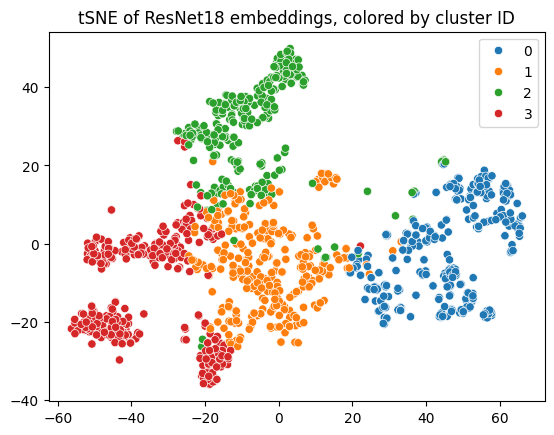

In [ ]:
sns.scatterplot(
    x=y_2d[:, 0], y=y_2d[:, 1],
    hue=clusters,
    palette="tab10",
    legend="full"
)
plt.title("tSNE of ResNet18 embeddings, colored by cluster ID")
plt.show()

# 7. Submission

In [ ]:
preds = [label_encoder.inverse_transform(np.array([c]))[0] for c in preds]	
ids = [p[:len(".jpg")] for p in test_ds.paths]

In [ ]:
sub = pd.DataFrame({"ID": ids, "prediction": preds})
sub.head()

,ID,prediction
0,0040,notumor
1,0503,meningioma
2,1029,pituitary
3,0065,pituitary
4,0437,notumor


In [ ]:
sub.to_csv("submission.csv", index=False)